In [1]:
pwd

'/data1/kishoretarafdar/src.port/multiresolution_kernels.v0/VolterraSys/nonlinear_kernels'

        Disable GPU: Force tensorflow to select CPU

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"    

        Select a GPU with a memory limit

In [ ]:
#%% # include ../dirx 
import tensorflow as tf
print(f"TensorFlow version {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)
mylibpath = [
    '/home/kishoretarafdar/bin',
    '/data1/kishoretarafdar/src2D/GIIR/mra'
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(1,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu
# select_gpu = gpus[gpu_id]
memory_limit = 16#32 #GB
select_a_gpu(gpus, gpu_id = 2, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

# from TFDWT.DWT1DFB import DWT1D, IDWT1D
# from TFDWT.DWT2DFB import DWT2D, IDWT2D


In [2]:
import matplotlib.pyplot as plt

In [3]:
x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
# x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0], dtype=tf.float32)
# x = tf.constant([0,1,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0], dtype=tf.float32)
# x = tf.constant([3.,0,7.,0], dtype=tf.float32)
x = tf.constant([1.,7.,11.,13.], dtype=tf.float32)
# x = tf.constant([3.,7.], dtype=tf.float32)
# x = tf.constant([1,1,1,1], dtype=tf.float32)
# x = tf.constant([21,3,4,5], dtype=tf.float32)
# x = tf.constant([.1,.1,.1,.1], dtype=tf.float32)
# x = tf.constant([1.,2], dtype=tf.float32)

In [4]:
# h = tf.constant([1,2], dtype=tf.float32)

        new QSI mra 2D layer

In [5]:
import tensorflow as tf
# from TFDWT.DWT1DFB import DWT1D, IDWT1D
from TFDWT.DWT3DFB import DWT3D, IDWT3D

@tf.keras.utils.register_keras_serializable()
class QSIVolterra3Dmra(tf.keras.layers.Layer):
    def __init__(self, filters=1, kernel_size=4, wave='haar', **kwargs):
        super().__init__(**kwargs)
        self.L = kernel_size
        self.filters = filters
        self.wave = wave
        # self.dwt2 = DWT2D(self.wave, clean=False)
        # self.idwt1 = IDWT1D(self.wave, clean=False)

    def build(self, input_shape):
        self.N = input_shape[1]         # sequence length
        self.axes = list(range(1, len(input_shape) - 1))
        self.dim = self.axes[-1]
        self.channels = input_shape[-1] # number of channels
        # Multi-channel kernel: (L, channels)
        # kernel_shape = (self.L, self.channels, self.filters)
        kernel_shape = [self.L] * self.dim + [self.channels, self.filters]
        self.h = self.add_weight(
            # shape=(self.L, self.channels),
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            name='UIR_kernel')
        super().build(input_shape)
        
    def make_mra_h2(self):
        ## make h2: ## Quadratic kernel outer product: (L, channels) x (L, channels) -> (L, L, channels)
        # if self.dim==1:
        #     h2 = tf.einsum('ico,jco->ijco', h, h)  # (L, L, channels)       
        # if self.dim==2:
        #     h2 = tf.einsum('ijco,klco->ijklco', h, h)  # (L, L, channels)
        if self.dim==3:
            h2 = tf.einsum('ijkco,pqrco->ijkpqrco', self.h, self.h)  # (L, L, channels)
        else:
            raise NotImplementedError("Hardcoded einsum strings supported for dim=1,2")
        self.h2 = h2
  
        def tf_pad_nd_volterra(h2, N, L, D):
            """
            Pad an ND Volterra kernel tensor from shape [L]*2D + [c, f] to [N]*2D + [c, f], using only TensorFlow ops.

            Args:
                h2: tf.Tensor, shape [L, ... L] (2D times), [c, f]
                N: int, target spatial size
                L: int, kernel spatial size
                D: int, number of spatial dimensions

            Returns:
                h2_padded: tf.Tensor, shape [N]*2D + [c, f]
            """
            pad = N - L
            t = h2
            for axis in range(2*D):  # pad all spatial axes (the first 2*D axes)
                # Compute the shape for the pad tensor to be appended at the end
                pad_shape_post = tf.concat([
                    tf.shape(t)[:axis],
                    [pad],
                    tf.shape(t)[axis+1:]
                ], axis=0)
                pad_tensor_post = tf.zeros(pad_shape_post, dtype=t.dtype)
                t = tf.concat([t, pad_tensor_post], axis=axis)
                # No pad at the beginning (left), only at the end (right)
            return t
        
        # if self.dim in [1,2]:
        #     ## new update ND (tf.pad limitation!)
        #     # Pad to (N, N, channels)
        #     # paddings = [
        #     #     [0, self.N - self.L],
        #     #     [0, self.N - self.L],
        #     #     [0, 0],
        #     #     [0, 0]
        #     # ]       
        #     paddings = [[0, self.N - self.L] for _ in range(self.dim*2)]  # spatial dims
        #     paddings += [[0, 0], [0, 0]]  # in_channels, out_channels
        #     h2_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
        # elif self.dim >=3: ## use custom padding if dim 3 or above
        h2_padded = tf_pad_nd_volterra(self.h2, self.N, self.L, self.dim)
        print('h2_padded', h2_padded.shape, h2_padded.dtype)

                
        def get_nd_shifted_h2(h2):
            """Create shifted h2 for vectorized trace convolution"""
            # h2: ([N]*D)*2 + [channels, filters]  (i.e., [N,...,N, N,...,N, c, f])
            # N: spatial size
            # D: number of spatial dimensions
            N = self.N
            D = self.dim

            # Output indices
            n = [tf.range(N) for _ in range(D)]
            k = [tf.range(N) for _ in range(D*2)]

            mesh = tf.meshgrid(*(n + k), indexing='ij')  # mesh of shape [N,...,N]*D + [N,...,N]*2D

            # For each spatial axis, build the shifted indices for both quadratic groups
            idx_list = []
            for d in range(D):
                n_d = mesh[d]
                k1_d = mesh[D + d]
                k2_d = mesh[D + D + d]
                idx_list.append((n_d - k1_d) % N)
            for d in range(D):
                n_d = mesh[d]
                k2_d = mesh[D + D + d]
                idx_list.append((n_d - k2_d) % N)

            idx = tf.stack(idx_list, axis=-1)  # shape: [N,...,N]*3D, 2D
            idx_flat = tf.reshape(idx, [-1, 2*D])
            gathered = tf.gather_nd(h2, idx_flat)
            output_shape = [N] * (3 * D) + [h2.shape[-2], h2.shape[-1]]
            gathered = tf.reshape(gathered, output_shape)
            return gathered    
        
        h2_shifted = get_nd_shifted_h2(h2_padded)
        print('h2shifted', h2_shifted.shape)

        # self.channels = input_shape[-1] # number of channels
        # # Multi-channel kernel: (L, channels)
        # kernel_shape = (self.L, self.channels, self.filters)
        # h = self.add_weight(
        #     # shape=(self.L, self.channels),
        #     shape=kernel_shape,
        #     initializer='glorot_uniform',
        #     trainable=True,
        #     name='UIR_kernel'
        # )
        
        # # Quadratic kernel outer product: (L, channels) x (L, channels) -> (L, L, channels)
        # h2 = tf.einsum('ico,jco->ijco', h, h)  # (L, L, channels)
        # self.h2 = h2
        # # Pad to (N, N, channels)
        # paddings = [
        #     [0, self.N - self.L],
        #     [0, self.N - self.L],
        #     [0, 0],
        #     [0, 0]
        # ]
        # h2_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
        # # self.h2_padded = h2_padded
        # ## creating h[n-k1,n-k2]
        # # N = Npoint
        # n = tf.range(self.N)
        # # Create circular indices for all possible shifts
        # # row_indices = tf.math.mod(n[:, tf.newaxis] - tf.range(N), L)  # [N, N]
        # row_indices = tf.math.mod(n[:, tf.newaxis] - n, self.N)
        # h2_rows_shifted = tf.gather(h2_padded, row_indices, axis=0)         # [N, N, N]
        # h2_columns_shifted = tf.gather(h2_rows_shifted, row_indices,   # [N, N, N]
        #                                 axis=2, batch_dims=1)
        # h2_shifted = h2_columns_shifted
        # # print('h2shifted', self.h2_shifted.shape)

        def make_mra_kernel3(h_shifted):
            print('h_shifted', h_shifted.shape)
            shape = tf.shape(h_shifted) # ijk pqr stu co, for example (4, 4, 4, 4, 4, 4, 1, 1)
            _ = tf.reshape(h_shifted, [shape[0]*shape[1]*shape[2]*shape[3]*shape[4]*shape[5], shape[6], shape[7] , shape[8], shape[9]*shape[10]])
            _ = DWT3D(self.wave, clean=False)(_) #stu
            _ = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4], shape[5], shape[6], shape[7], shape[8], shape[9],shape[10]])
            _ = tf.reshape(_,  [shape[0]*shape[1]*shape[2], shape[3], shape[4], shape[5], shape[6]*shape[7]*shape[8]*shape[9]*shape[10]])
            _ = DWT3D(self.wave, clean=False)(_) #pqr
            _ = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4], shape[5], shape[6], shape[7], shape[8], shape[9],shape[10]])
            _ = tf.transpose(_, perm=[3,4,5, 0,1,2, 6,7,8,9,10])
            _ = tf.reshape(_, [shape[0]*shape[1]*shape[2], shape[3], shape[4], shape[5], shape[6]*shape[7]*shape[8]*shape[9]*shape[10]])
            _ = DWT3D(self.wave, clean=False)(_) #ijk
            _ = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4], shape[5], shape[6], shape[7], shape[8], shape[9],shape[10]])
            H = tf.transpose(_, perm=[3,4,5, 0,1,2, 6,7,8,9,10])
            return H
        H = make_mra_kernel3(h2_shifted)
        print('H',H.shape)
        return H
        



        # ## update this for batched multichannel
        # _ = tf.expand_dims(tf.cast(h2_shifted, dtype=tf.float32), axis=-1)
        # h_init = DWT2D(self.wave, clean=False)(_)
        # print(tf.squeeze(h_init))

        # H = tf.expand_dims(
        #     tf.transpose(
        #         DWT1D(wave, clean=False)(tf.transpose(tf.squeeze(h_init, axis=-1), perm=[1,0,2])),
        #         perm=[1,0,2]),axis=-1)
        # H[:,:,:,0]



        


    def call(self, x):
        # x: (batch, N, channels)
        x2 = tf.einsum('bijkc,bpqrc->bijkpqrc', x, x)  # (batch, N, N, channels)
        print('x2', x2.shape)

        def dwt6(x2): 
            shape = tf.shape(x2)  ## b ijk pqr c
            _ = tf.reshape(x2, [shape[0]*shape[1]*shape[2]*shape[3], shape[4], shape[5], shape[6], shape[7]])
            # print('_',_.shape)
            _ = DWT3D(self.wave, clean=False)(_)
            _ = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4], shape[5], shape[6], shape[7]])
            _ = tf.transpose(_, perm=[0, 4,5,6, 1,2,3, 7])
            _ = tf.reshape(_, [shape[0]*shape[1]*shape[2]*shape[3], shape[4], shape[5], shape[6], shape[7]])
            _ = DWT3D(self.wave, clean=False)(_)
            _ = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3], shape[4], shape[5], shape[6], shape[7]])
            return tf.transpose(_, perm=[0, 4,5,6, 1,2,3, 7])
        α2 = dwt6(x2)
        print('α2', α2.shape)
        H = self.make_mra_h2()
        ## Fitlering
        β = tf.einsum('ijkpqrstuco,bpqrstuc->bijko', H, α2)
        print('β', β.shape)

        # print(x2.shape, self.h2_shifted.shape)
        # y = tf.einsum('ijkco, bjkc->bio', self.h2_shifted, x2)
        # y2 = self.idwt1(β)
        y2 = IDWT3D(self.wave, clean=False)(β)
        print('y2', y2.shape)
        return y2
        
        

    def get_filter(self):
        return self.h2

        
if __name__ =='__main__':

    # Define input shape and build the model for summary
    N = 4
    input_shape = (N, N, N, 1)  # Replace N with the actual size of x
    inputs = tf.keras.Input(shape=input_shape)

    # Create an instance of the custom layer
    # h2 = np.array([[1, 2], 
    #           [1, 3]]).astype(np.float32)
    # H = TraceConv1Dio(kernel=tf.expand_dims(h2, axis=-1))
    # (tf.expand_dims(tf.expand_dims(x2,axis=0),axis=-1))

    #conv1d_filters=32, conv1d_kernel_size=3, 
    #  conv2d_filters=32, conv2d_kernel_size=3)

    # Apply the custom layer to the inputs
    H = QSIVolterra3Dmra()
    outputs = H(inputs)

    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    # Print the model summary
    model.summary()


x2 (None, 4, 4, 4, 4, 4, 4, 1)
α2 (None, 4, 4, 4, 4, 4, 4, 1)
h2_padded (4, 4, 4, 4, 4, 4, 1, 1) <dtype: 'float32'>
h2shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
h_shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
H (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
β (None, 4, 4, 4, 1)
y2 (None, 4, 4, 4, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 4, 4, 4, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qsi_volterra3_dmra              │ (None, 4, 4, 4, 1)     │            64 │
│ (QSIVolterra3Dmra)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64 (256.00 B)

 Trainable params: 64 (256.00 B)

 Non-trainable params: 0 (0.00 B)

        Fit a sample model

In [6]:
# Functional model
N, channels, filters = 4, 1, 1
# input_shape = (N, channels)  # Replace N with the actual size of x        #1D
# input_shape = (N, N, channels)  # Replace N with the actual size of x     #2D
input_shape = (N, N, N, channels)  # Replace N with the actual size of x    #3D
inputs = tf.keras.Input(shape=input_shape)

# Apply the custom layer to the inputs
H = QSIVolterra3Dmra(filters=filters)
outputs = H(inputs)

# Build the model
model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='mse', jit_compile=False)
model.summary()

# Random data
## 1D
# inputs_data = tf.random.normal((1, N, 1))
# targets = tf.random.normal((1, N, 1))
## 2D
# inputs_data = tf.random.normal((1, N, N, 1))
# targets = tf.random.normal((1, N, N, 1))
## 3D
inputs_data = tf.random.normal((1, N, N, N, 1))
targets = tf.random.normal((1, N, N, N, 1))


# Training loop for 5 epochs
epochs=5
# for epoch in range(5):
history = model.fit(inputs_data, targets, epochs=5, verbose=1)

x2 (None, 4, 4, 4, 4, 4, 4, 1)
α2 (None, 4, 4, 4, 4, 4, 4, 1)
h2_padded (4, 4, 4, 4, 4, 4, 1, 1) <dtype: 'float32'>
h2shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
h_shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
H (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
β (None, 4, 4, 4, 1)
y2 (None, 4, 4, 4, 1)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 4, 4, 4, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qsi_volterra3_dmra_1            │ (None, 4, 4, 4, 1)     │            64 │
│ (QSIVolterra3Dmra)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64 (256.00 B)

 Trainable params: 64 (256.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
x2 (None, 4, 4, 4, 4, 4, 4, 1)
α2 (None, 4, 4, 4, 4, 4, 4, 1)
h2_padded (4, 4, 4, 4, 4, 4, 1, 1) <dtype: 'float32'>
h2shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
h_shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
H (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
β (None, 4, 4, 4, 1)
y2 (None, 4, 4, 4, 1)
x2 (None, 4, 4, 4, 4, 4, 4, 1)
α2 (None, 4, 4, 4, 4, 4, 4, 1)
h2_padded (4, 4, 4, 4, 4, 4, 1, 1) <dtype: 'float32'>
h2shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
h_shifted (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
H (4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1)
β (None, 4, 4, 4, 1)
y2 (None, 4, 4, 4, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 3.7931
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 3.6576
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 3.5275
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 3.4028
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 3.2834


In [12]:
# Generate a random multi-channel input
import numpy as np
np.random.seed(42)
batch_size, N, channels, filters = 1, N, 1, 1
x_np = np.random.randn(batch_size, N, N, N, channels).astype(np.float32)
x = tf.constant(x_np)
x.shape, x.dtype
# Instantiate the layer
# H = QSIVolterra1D(filters=filters)

# Call the layer
# ylay = H(x)

# print("Input shape:", x.shape)
# print("Output shape:", ylay.shape)
# print("Output (first batch example):\n", ylay[0].numpy())

(TensorShape([1, 4, 4, 4, 1]), tf.float32)

In [14]:
model.predict(x).shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


(1, 4, 4, 4, 1)

In [15]:
# ylay = H(tf.expand_dims(tf.expand_dims(x, axis=-1), axis=0))
ylay = H(x)
ylay = tf.squeeze(ylay).numpy()
ylay

x2 (1, 4, 4, 4, 4, 4, 4, 1)
α2 (1, 4, 4, 4, 4, 4, 4, 1)
β (1, 4, 4, 4, 1)
y2 (1, 4, 4, 4, 1)


array([[[1.1338579e-02, 1.8272028e+00, 1.9742806e-02, 1.6557731e-02],
        [2.8194969e+00, 2.8942192e-02, 3.1403139e-02, 8.6067086e-03],
        [7.6694214e-03, 4.1906677e-02, 9.4507463e-02, 6.4305156e-01],
        [1.8460235e-02, 7.3147804e-01, 2.0918088e+00, 6.6931421e-01]],

       [[2.9241366e+00, 3.5376823e-01, 7.5639329e+00, 3.1014958e-01],
        [6.0484800e-02, 4.9292874e-02, 8.5086361e-02, 4.8944449e-01],
        [4.7781461e-01, 3.5899377e-01, 3.9706099e-01, 7.5550020e-01],
        [3.1163929e-02, 2.0122526e+00, 2.3223817e-01, 2.7978280e+00]],

       [[7.6555437e-01, 3.6456200e-01, 7.9017878e-01, 4.2112801e-02],
        [3.8130206e-01, 1.2338943e-01, 2.8675551e+00, 1.8256494e-01],
        [6.1467770e-02, 3.8676926e-01, 6.6036575e-02, 6.4148337e-01],
        [2.8775984e-01, 1.5278506e-01, 2.8706011e-01, 1.5158675e-04]],

       [[1.4518429e+00, 3.4008510e-03, 5.3718262e-03, 1.8581553e-01],
        [6.6588052e-02, 4.0959757e-02, 4.7242028e-01, 7.0017117e-01],
        [2.788

In [16]:
h2 = tf.squeeze(H.get_filter())
h2

<tf.Tensor: shape=(4, 4, 4, 4, 4, 4), dtype=float32, numpy=
array([[[[[[ 1.93957239e-02,  1.86829567e-02,  1.97659452e-02,
             1.48344832e-02],
           [-3.88357835e-03,  5.15154516e-03,  1.03060026e-02,
            -1.38286864e-02],
           [ 2.29201484e-02, -7.19054695e-03,  1.10790394e-02,
            -3.01214661e-02],
           [ 1.88929103e-02, -2.82660909e-02, -2.93418989e-02,
            -1.58777088e-02]],

          [[-1.83940977e-02,  1.10717164e-02,  1.85761936e-02,
            -1.59690659e-02],
           [ 9.37784091e-03,  2.31773779e-02, -6.96335547e-03,
            -1.59540121e-02],
           [-1.49086677e-03, -1.29660344e-04,  1.46555481e-03,
             1.24503532e-03],
           [-1.80666987e-03, -4.60346229e-03,  2.72851065e-02,
            -6.91800704e-03]],

          [[-1.45872282e-02,  2.21191812e-02,  6.11574575e-03,
            -1.55079849e-02],
           [-1.20017643e-03, -2.42727324e-02,  1.21012479e-02,
             3.54884053e-03],
      

In [9]:
x.shape

TensorShape([1, 128, 1])

---

In [10]:
# x = x[0,:,0]

In [ ]:
# x = tf.squeeze(x)

h_padded tf.Tensor(
[[ 0.15820359  0.11617792 -0.01432928 ...  0.          0.
   0.        ]
 [ 0.11617792  0.08531608 -0.0105228  ...  0.          0.
   0.        ]
 [-0.01432928 -0.0105228   0.00129787 ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]], shape=(128, 128), dtype=float32)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 128)
(128, 1

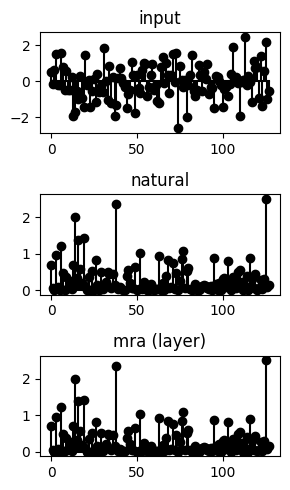

In [ ]:


# L = h2.shape[0] #filter length
# # n = tf.range(L) 
# Npoint = x.shape[0]
# # Npoint = len(x)
# paddings = [
#         [0, Npoint - L],  # Depth dimension
#         [0, Npoint - L]
#         #    0,
#         #    0,
#         ]
# # x
# Npoint, paddings
# h_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
# print('h_padded', h_padded)
# h_padded.shape



# x2 = tf.einsum('i,j->ij',x,x)
# x2

# ### NAtural domain (alternative)
# # q2 = tf.einsum('ijk,jk->i', h_columns_shifted, x2) ## faster
# # slower version 
# import numpy as np
# def compute_q2(x2, h2):
#     N = x2.shape[0]
#     q2 = np.zeros(N).astype(float)
#     for n in range(N):
#         q2[n] = np.sum(h2 * x2[np.mod(n-np.arange(N), N),:][:, np.mod(n-np.arange(N), N)])
#         print(x2[np.mod(n-np.arange(N), N),:][:, np.mod(n-np.arange(N), N)].shape)
#     return q2

# q2 = compute_q2(x2.numpy(),h_padded.numpy())
# q2

# plt.figure(figsize=(3,5))
# plt.subplot(3,1,1), plt.stem(tf.squeeze(x).numpy(),'k', basefmt="k"), plt.title(f'input')
# plt.subplot(3,1,2), plt.stem(tf.squeeze(q2).numpy(),'k', basefmt="k"), plt.title(f'natural')
# # plt.subplot(3,1,3), plt.stem(tf.squeeze(y2).numpy(),'k', basefmt="k"), plt.title(f'Volterra (haar)')
# plt.subplot(3,1,3), plt.stem(tf.squeeze(ylay).numpy(),'k', basefmt="k"), plt.title(f'mra (layer)')

# plt.tight_layout()

In [13]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)